# The Application Numbers Game (SOLUTION)

**The bias.** When people encounter a probability below 50%, they tend to treat it as
*"it won't happen."* Above 50%, they treat it as *"it will happen."* This is called
**binary thinking** — collapsing a probability into a yes/no prediction before the
outcome has occurred. It feels natural, but it leads to systematically wrong decisions.

**The scenario.** A friend of yours wants to break into sports journalism. After some
research, you find that candidates who apply to open roles at sports outlets have roughly
a 3% chance of receiving an offer. Your friend is discouraged: *"3% is basically zero —
why bother applying?"* This exercise will show, through simulation, exactly why that
reasoning is wrong.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

P_SINGLE = 0.03    # per-application offer probability
P_HIGH   = 0.10    # per-application probability in a stronger-fit scenario
N_APPS   = 30      # applications in a typical search
N_SIMS   = 100  # simulation runs
TARGET   = 0.90    # target confidence of getting at least one offer

RNG = np.random.default_rng(42)

## 1. The bias in action — one application at 3%

Binary thinking predicts: *"3% is basically zero — it won't happen."*
Simulate 10,000 single applications at `P_SINGLE` and measure how often that prediction is wrong.

In [2]:
single_outcomes = RNG.binomial(1, P_SINGLE, N_SIMS)
empirical_rate  = single_outcomes.mean()

print(f"Binary thinking: '20% < 50% — it won't happen'")
print(f"Simulation ({N_SIMS:,} tries): offer received {empirical_rate:.1%} of the time")
print(f"Binary thinking was wrong on roughly 1 in every {round(1/empirical_rate):.0f} applications")

Binary thinking: '20% < 50% — it won't happen'
Simulation (100 tries): offer received 2.0% of the time
Binary thinking was wrong on roughly 1 in every 50 applications


A 3% hit rate means the binary thinker is wrong on 1 in every 33 applications on average —
but they never find out, because they already decided it wouldn't happen and didn't apply.

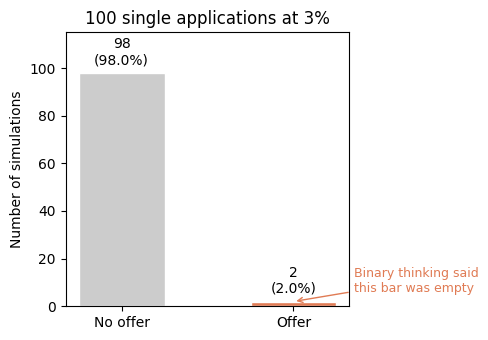

In [3]:
labels  = ['No offer', 'Offer']
counts  = [N_SIMS - single_outcomes.sum(), single_outcomes.sum()]

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(labels, counts, color=['#cccccc', '#e07b54'], edgecolor='white', width=0.5)
ax.bar_label(bars, fmt=lambda v: f'{int(v):,}\n({v/N_SIMS:.1%})', padding=4, fontsize=10)
ax.set(title=f'{N_SIMS} single applications at {P_SINGLE:.0%}',
       ylabel='Number of simulations', ylim=(0, N_SIMS * 1.15))
ax.annotate('Binary thinking said\nthis bar was empty',
            xy=(1, counts[1]), xytext=(1.35, counts[1] + N_SIMS * 0.04),
            arrowprops=dict(arrowstyle='->', color='#e07b54'), color='#e07b54', fontsize=9)
plt.tight_layout()
plt.show()

## 2. The overconfidence mirror — one application at 10%

Binary thinking predicts: *"10% is above zero, so it'll probably work out."*
Simulate 10,000 single applications at `P_HIGH` and count how often that prediction fails.

In [4]:
high_outcomes = RNG.binomial(1, P_HIGH, N_SIMS)
failure_rate  = 1 - high_outcomes.mean()

print(f"Binary thinking: '75% > 50% — it will happen'")
print(f"Simulation ({N_SIMS:,} tries): no offer {failure_rate:.1%} of the time")
print(f"Binary thinking was wrong roughly 1 in every {round(1/failure_rate):.0f} applications")

Binary thinking: '75% > 50% — it will happen'
Simulation (100 tries): no offer 89.0% of the time
Binary thinking was wrong roughly 1 in every 1 applications


Even at 10%, the binary thinker is wrong roughly 1 in 10 times. Treating any single
application as a near-certainty — however strong the fit — is a real risk.

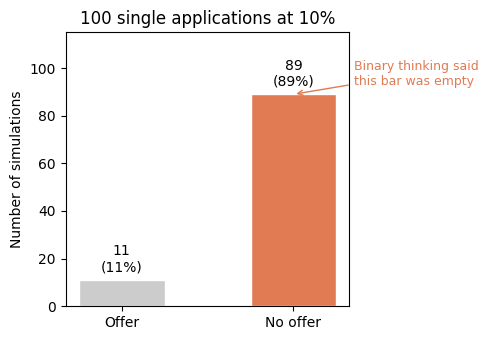

In [5]:
labels2 = ['Offer', 'No offer']
counts2 = [high_outcomes.sum(), N_SIMS - high_outcomes.sum()]

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(labels2, counts2, color=['#cccccc', '#e07b54'], edgecolor='white', width=0.5)
ax.bar_label(bars, fmt=lambda v: f'{int(v):,}\n({v/N_SIMS:.0%})', padding=4, fontsize=10)
ax.set(title=f'{N_SIMS} single applications at {P_HIGH:.0%}',
       ylabel='Number of simulations', ylim=(0, N_SIMS * 1.15))
ax.annotate('Binary thinking said\nthis bar was empty',
            xy=(1, counts2[1]), xytext=(1.35, counts2[1] + N_SIMS * 0.04),
            arrowprops=dict(arrowstyle='->', color='#e07b54'), color='#e07b54', fontsize=9)
plt.tight_layout()
plt.show()

## 3. Stack the applications

Binary thinking about 30 applications at 3%: *"None of these will pan out."*
Simulate `N_SIMS` full searches — each with `N_APPS` applications — and
compute P(at least one offer).

In [6]:
search_outcomes = RNG.binomial(N_APPS, P_SINGLE, N_SIMS)
p_at_least_one  = (search_outcomes >= 1).mean()
analytical      = 1 - (1 - P_SINGLE) ** N_APPS

print(f"Binary thinking: '20% x {N_APPS} applications — none will pan out'")
print(f"Simulation:  P(at least one offer) = {p_at_least_one:.1%}")
print(f"Analytical:  1 - (1 - {P_SINGLE})^{N_APPS} = {analytical:.1%}")

Binary thinking: '20% x 30 applications — none will pan out'
Simulation:  P(at least one offer) = 56.0%
Analytical:  1 - (1 - 0.03)^30 = 59.9%


Thirty applications at 3% yields at least one offer roughly 60% of the time.
Binary thinking about each individual application would have your friend give up
before the numbers have a chance to work in their favour.

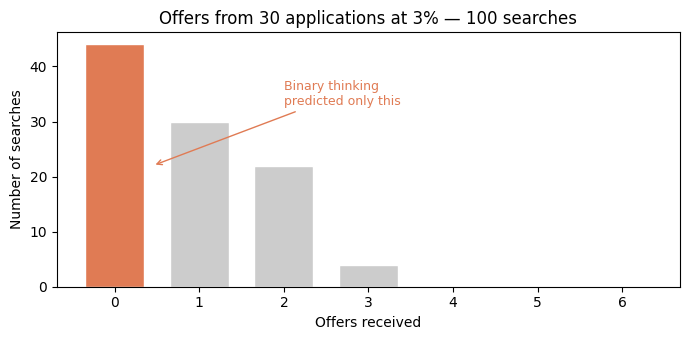

In [7]:
bins = range(0, 8)

fig, ax = plt.subplots(figsize=(7, 3.5))
n, _, patches = ax.hist(search_outcomes, bins=bins, align='left', rwidth=0.7,
                         color='#cccccc', edgecolor='white')
patches[0].set_facecolor('#e07b54')
ax.set(title=f'Offers from {N_APPS} applications at {P_SINGLE:.0%} — {N_SIMS:,} searches',
       xlabel='Offers received', ylabel='Number of searches')
ax.annotate('Binary thinking\npredicted only this',
            xy=(0.45, n[0] * 0.5), xytext=(2, n[0] * 0.75),
            arrowprops=dict(arrowstyle='->', color='#e07b54'), color='#e07b54', fontsize=9,
            ha='left')
plt.tight_layout()
plt.show()

## 4. The full picture

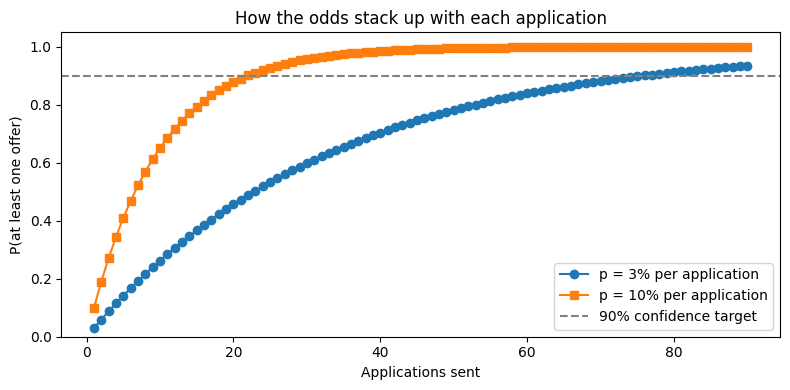

In [8]:
ns     = np.arange(1, 91)
p_low  = 1 - (1 - P_SINGLE) ** ns
p_high = 1 - (1 - P_HIGH)   ** ns

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ns, p_low,  '-o', label='p = 3% per application')
ax.plot(ns, p_high, '-s', label='p = 10% per application')
ax.axhline(TARGET, ls='--', color='gray', label=f'{TARGET:.0%} confidence target')
ax.set(xlabel='Applications sent', ylabel='P(at least one offer)',
       title='How the odds stack up with each application', ylim=(0, 1.05))
ax.legend()
plt.tight_layout()
plt.show()

## 5. Find your number

In [9]:
n_needed = math.ceil(math.log(1 - TARGET) / math.log(1 - P_SINGLE))
print(f"Analytical: {n_needed} applications for {TARGET:.0%} confidence at p = {P_SINGLE:.0%}")

# Verify with simulation
sim_probs = [(RNG.binomial(n, P_SINGLE, N_SIMS) >= 1).mean() for n in range(1, n_needed + 3)]
sim_crossover = next(n for n, p in enumerate(sim_probs, 1) if p >= TARGET)
print(f"Simulation confirms: {TARGET:.0%} confidence reached at {sim_crossover} applications")

Analytical: 76 applications for 90% confidence at p = 3%
Simulation confirms: 90% confidence reached at 61 applications


Your friend needs to send roughly 76 applications to hit 90% confidence at 3% per application.
That sounds like a lot — but it is exactly what the math requires, and binary thinking
is the only reason it feels surprising.

## 6. Takeaway

Binary thinking treats 3% as "won't happen" — but 30 applications yield at least one
offer roughly 60% of the time, and 76 applications get your friend to 90% confidence.
The bias cuts both ways: it leads people to give up too early because 3% feels like zero,
and to over-rely on a single strong application because 10% feels like a guarantee.
Simulation makes both errors visible by replacing intuition with counts.